# Section 1 - Importation and Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import random
import joblib
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score


In [ ]:
import sys
from pathlib import Path

# Define the Root Directory of the Project
PROJECT_ROOT = Path.cwd().parent

# Data Directory based on the project root, matching the folder name "Data/Processed Data"
DATA_DIR = PROJECT_ROOT / "Data" / "Processed Data"

# Results Hierarchy
RESULTS_DIR = PROJECT_ROOT / "Results"
MODEL_DIR = RESULTS_DIR / "Models"
PREDICTION_DIR = RESULTS_DIR / "Predictions"

# Adding root to sys.path for imports
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Diagnostic Prints
print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Source:  {DATA_DIR}")
print(f"Model Path:   {MODEL_DIR}")
print(f"Predictions:  {PREDICTION_DIR}")

# Test if we can see the data file aka. if the path set-up is correct and the file exists
test_file = DATA_DIR / "val_processed.csv"
if test_file.exists():
    print(f"Success! Found {test_file}")
else:
    raise FileNotFoundError(f"Missing expected file: {test_file}")

Project Root: c:\Users\Elias\Documents\SCANIA Component X
Data Source:  c:\Users\Elias\Documents\SCANIA Component X\Data\Processed Data
Model Path:   c:\Users\Elias\Documents\SCANIA Component X\Results\Models
Predictions:  c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions
Success! Found c:\Users\Elias\Documents\SCANIA Component X\Data\Processed Data\val_processed.csv


In [ ]:
import importlib
import utils

importlib.reload(utils)

# Set the device to GPU if available, otherwise use CPU. IMPORTANT! USE GPU IF AVAILABLE, OTHERWISE TRAINING WILL BE EXTREMLEY SLOW.
DEVICE = utils.DEVICE

if torch.cuda.is_available():
    print(f"Using CUDA at: {torch.cuda.get_device_name(0)}")
else:
    print("Warning. CUDA not available. Using CPU, which may be slow for training.")

Using CUDA at: NVIDIA GeForce RTX 4060


In [ ]:
# Importing the data files into pandas DataFrames. 
train_data = pd.read_csv(DATA_DIR / 'train_processed.csv')
val_data   = pd.read_csv(DATA_DIR / 'val_processed.csv')
test_data  = pd.read_csv(DATA_DIR / 'test_processed.csv')


print("=== LOADED SUCCESSFULLY ===")
print(f"Training Data:   {train_data.shape}")
print(f"Validation Data: {val_data.shape}")
print(f"Test Data: {test_data.shape}")

=== LOADED SUCCESSFULLY ===
Training Data:   (1122267, 108)
Validation Data: (196227, 108)
Test Data: (198140, 108)


In [5]:
import json
# Double checking the sizes of the loaded data and labels
print("=== Dataset Shapes ===")
print(f"Training Data: {train_data.shape}")
print(f"Validation Data: {val_data.shape}")
print('\n')

# Double cheking that no NaN values have snuck in
print("=== Checking for Missing values  ===")
print(f"Training Data: {train_data.isnull().sum().sum()}")
print(f"Validation Data: {val_data.isnull().sum().sum()}")
print('\n')

print("=== Label Distributions ===")
print(f"Train labels:\n{train_data['label'].value_counts()}")
print(f"Validation labels:\n{val_data['label'].value_counts()}")

train_data.head()
with open(PROJECT_ROOT / 'Results' / 'Models' / 'hyperparams.json', 'r') as f:
    hp = json.load(f)

=== Dataset Shapes ===
Training Data: (1122267, 108)
Validation Data: (196227, 108)


=== Checking for Missing values  ===
Training Data: 0
Validation Data: 0


=== Label Distributions ===
Train labels:
label
0    1096527
1      25740
Name: count, dtype: int64
Validation labels:
label
0    191150
1      5077
Name: count, dtype: int64


# Section 2 - Multi-Seed Robustness Verification
Single runs of LSTM and TCN can vary significantly depending on the seed, making point estimates unreliable for model comparison. This section trains and evaluates both models across 30 independent seeds to obtain a robust distribution of test cost rather than a single figure. For both temporal models, 30 different random seeds were selected partly supported by the rule of thumb surrounding the central limit theorem (CLT), which often cites n≈30 as a practical minimum threshold for the sample mean distribution to approximate a normal distribution, regardless of the underlying distribution shape. This provides a reasonably stable estimate of the average test cost per model. However, the significance test in Section 3.2 uses Mann Whitney U rather than a t test, as we do not wish to rely on a strict normality assumption for the cost distribution across seeds, 30 seeds thus offers a reasonable trade off between computation time and statistical robustness, rather than a guarantee of normality itself.

In [6]:
SEQ_LEN = hp['SEQ_LEN']

X_train_seq, y_train_seq, train_seq_ids = utils.generate_sequential_data(train_data, 'label', SEQ_LEN)
X_val_seq, y_val_seq, val_seq_ids = utils.generate_sequential_data(val_data, 'label', SEQ_LEN)
X_test_seq, y_test_seq, test_seq_ids = utils.generate_sequential_data(test_data, 'label', SEQ_LEN)


In [7]:
val_labels_full  = pd.read_csv(PROJECT_ROOT / "Data" / 'validation_labels.csv')
test_labels_full = pd.read_csv(PROJECT_ROOT / "Data" / 'test_labels.csv')

val_labels_aligned  = val_labels_full.set_index('vehicle_id').loc[list(val_seq_ids),  'class_label'].values
test_labels_aligned = test_labels_full.set_index('vehicle_id').loc[list(test_seq_ids), 'class_label'].values

## 2.1 - LSTM

In [21]:
SEEDS = [42, 123, 2024, 7, 99, 1337, 2026, 300, 88, 1, 17, 55, 200, 404, 999, 9, 44, 54, 76, 545 , 9999, 898 , 1234, 4321, 2025, 5555, 7777, 8888, 1010, 2023]

In [14]:
lstm_results = utils.run_verification(
    model_name    = 'LSTM',
    hp            = hp,           
    seeds         = SEEDS,
    utils_module  = utils,
    X_train=X_train_seq, y_train=y_train_seq,
    X_val=X_val_seq,     y_val=y_val_seq,
    X_test=X_test_seq,
    val_labels_mc = val_labels_aligned,
    test_labels_mc= test_labels_aligned,
    model_dir     = MODEL_DIR,
)


  LSTM | seed = 42
Epoch 1/1000 - Time: 1.65s - Train: 0.0368 - Val: 0.0256 - Val AUC-PR: 0.0209
___________________________________
Epoch 2/1000 - Time: 1.49s - Train: 0.0365 - Val: 0.0254 - Val AUC-PR: 0.0229
___________________________________
Epoch 3/1000 - Time: 1.57s - Train: 0.0362 - Val: 0.0252 - Val AUC-PR: 0.0251
___________________________________
Epoch 4/1000 - Time: 1.55s - Train: 0.0362 - Val: 0.0250 - Val AUC-PR: 0.0272
___________________________________
Epoch 5/1000 - Time: 1.58s - Train: 0.0360 - Val: 0.0249 - Val AUC-PR: 0.0292
___________________________________
Epoch 6/1000 - Time: 1.54s - Train: 0.0359 - Val: 0.0248 - Val AUC-PR: 0.0310
___________________________________
Epoch 7/1000 - Time: 1.36s - Train: 0.0359 - Val: 0.0247 - Val AUC-PR: 0.0327
___________________________________
Epoch 8/1000 - Time: 1.45s - Train: 0.0357 - Val: 0.0246 - Val AUC-PR: 0.0342
___________________________________
Epoch 9/1000 - Time: 1.53s - Train: 0.0357 - Val: 0.0245 - Val AUC-P

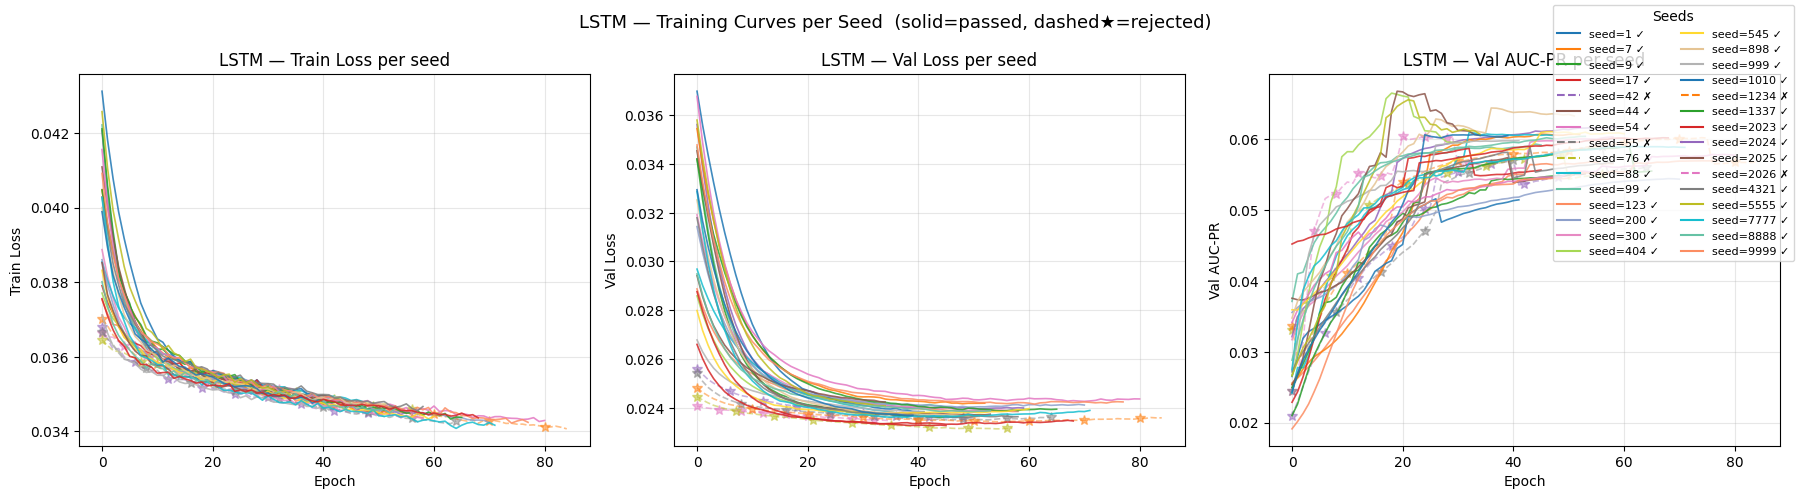

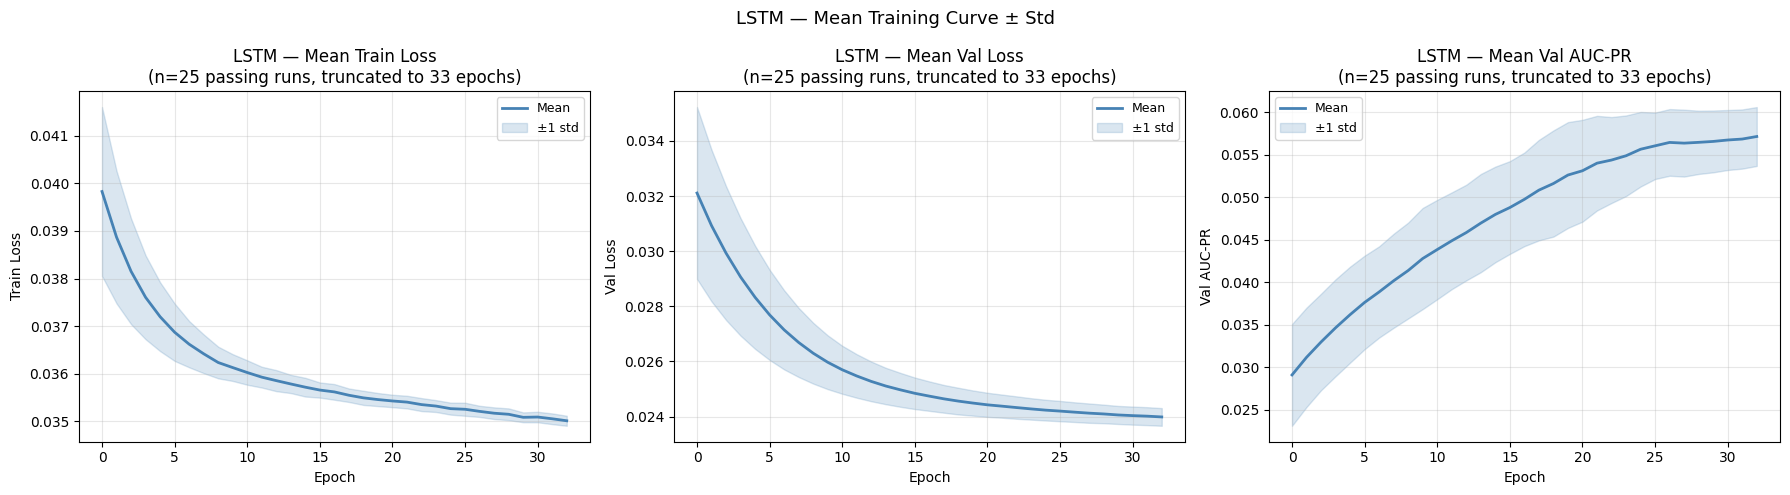

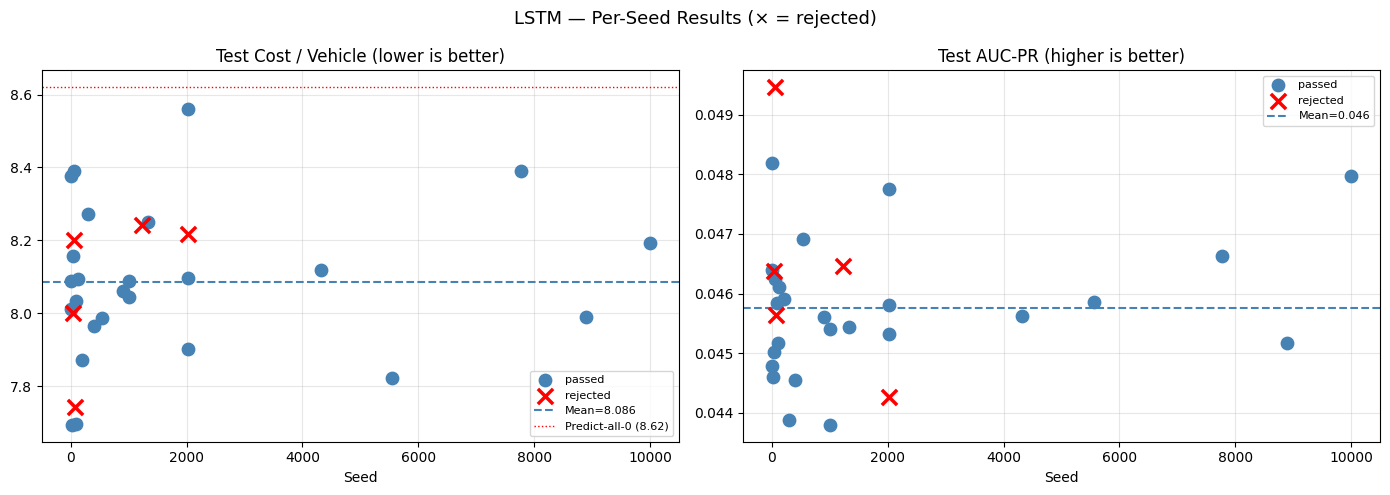

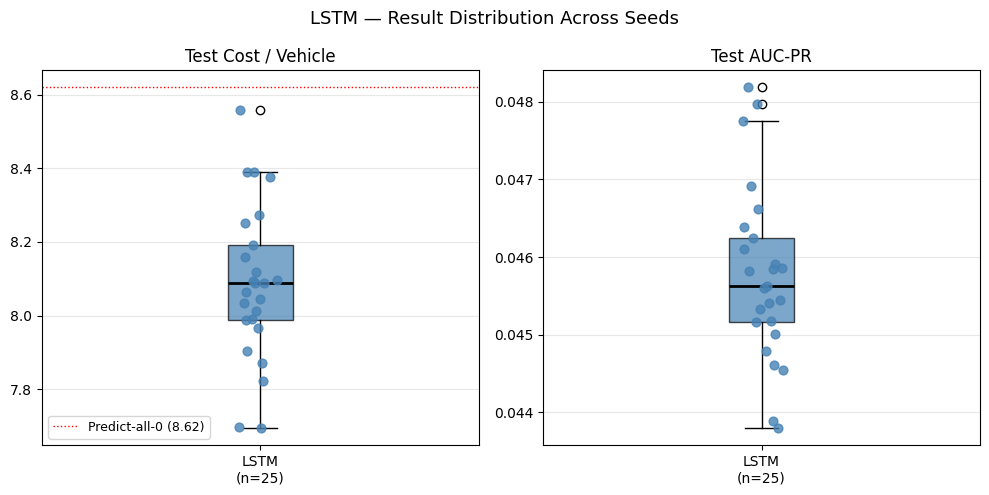

{'val_auc_pr': {'mean': 0.05851871348026449, 'std': 0.0027682961605608038, 'n': 25}, 'val_cost_per_veh': {'mean': 7.6825445897740785, 'std': 0.2353145657886392, 'n': 25}, 'test_auc_pr': {'mean': 0.04576075926658397, 'std': 0.0011047052484734197, 'n': 25}, 'test_auc_roc': {'mean': 0.6512065909632793, 'std': 0.005684710432220939, 'n': 25}, 'test_recall': {'mean': 0.6608450704225352, 'std': 0.06300924257496718, 'n': 25}, 'test_precision': {'mean': 0.04199629508969152, 'std': 0.002020407265916553, 'n': 25}, 'test_f1': {'mean': 0.07888542621276849, 'std': 0.0031442828782081815, 'n': 25}, 'test_cost_per_veh': {'mean': 8.086398414271557, 'std': 0.20693754918378238, 'n': 25}, 'optimal_threshold': {'mean': 0.45879999999999993, 'std': 0.005153639490690054, 'n': 25}}


In [15]:
import matplotlib.pyplot as plt
utils.plot_all(lstm_results, 'LSTM')
print(lstm_results['summary'])

#### Conclusion

Out of 30 executed seeds, 25 passed the stability check (5 rejected, marked with × in the scatter and box plots). The training curves (figures 1 and 2) show consistent convergence across all approved seeds, both train and val loss decrease smoothly without signs of divergence or instability, and the relatively narrow ±1 std corridor around the mean curve (figure 2) suggests that LSTM training dynamics are robust to seed choice itself.

The test results (figures 3 and 4) however display a clearly wider spread: test cost per vehicle varies between approximately 7.70 and 8.56 across the approved seeds, with a mean of 8.086 (± 0.207 std). All approved runs lie below the predict all 0 baseline (8.62), but the margin is small in places, several seeds land near 8.4 to 8.56. Test AUC PR is relatively more stable, concentrated between roughly 0.044 and 0.048 with a mean of 0.046.

Overall, this indicates that the LSTM training process is stable, but that its final test performance is moderately sensitive to seed choice, which is precisely the type of variation motivating the multi seed verification in this section rather than relying on a single run (compare the inconsistent single run figures in the model evaluation notebook).

## 2.2 - TCN

In [29]:
tcn_results = utils.run_verification(
    model_name    = 'TCN',
    hp            = hp,           
    seeds         = SEEDS,
    utils_module  = utils,
    X_train=X_train_seq, y_train=y_train_seq,
    X_val=X_val_seq,     y_val=y_val_seq,
    X_test=X_test_seq,
    val_labels_mc = val_labels_aligned,
    test_labels_mc= test_labels_aligned,
    model_dir     = MODEL_DIR,
)


  TCN | seed = 42
Epoch 1/1000 - Time: 22.77s - Train: 0.0641 - Val: 0.0197 - Val AUC-PR: 0.0350
___________________________________
Epoch 2/1000 - Time: 22.84s - Train: 0.0576 - Val: 0.0191 - Val AUC-PR: 0.0375
___________________________________
Epoch 3/1000 - Time: 23.31s - Train: 0.0556 - Val: 0.0192 - Val AUC-PR: 0.0399
___________________________________
Epoch 4/1000 - Time: 23.26s - Train: 0.0538 - Val: 0.0196 - Val AUC-PR: 0.0417
___________________________________
Epoch 5/1000 - Time: 23.40s - Train: 0.0523 - Val: 0.0200 - Val AUC-PR: 0.0443
___________________________________
Epoch 6/1000 - Time: 23.28s - Train: 0.0512 - Val: 0.0203 - Val AUC-PR: 0.0463
___________________________________
Epoch 7/1000 - Time: 23.19s - Train: 0.0499 - Val: 0.0204 - Val AUC-PR: 0.0485
___________________________________
Epoch 8/1000 - Time: 23.17s - Train: 0.0500 - Val: 0.0208 - Val AUC-PR: 0.0484
___________________________________
Epoch 9/1000 - Time: 22.94s - Train: 0.0493 - Val: 0.0212 - V

c:\Users\Elias\Documents\SCANIA Component X\.venv\Lib\site-packages\numpy\lib\_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


  ✓ PASS
  Val AUC-PR:    0.0528
  Val cost/veh:  7.9021
  Test cost/veh: 7.2718
  Threshold:     0.46

  TCN | seed = 55
Epoch 1/1000 - Time: 23.11s - Train: 0.0612 - Val: 0.0211 - Val AUC-PR: 0.0380
___________________________________
Epoch 2/1000 - Time: 22.97s - Train: 0.0582 - Val: 0.0217 - Val AUC-PR: 0.0411
___________________________________
Epoch 3/1000 - Time: 23.36s - Train: 0.0567 - Val: 0.0222 - Val AUC-PR: 0.0437
___________________________________
Epoch 4/1000 - Time: 23.08s - Train: 0.0529 - Val: 0.0225 - Val AUC-PR: 0.0453
___________________________________
Epoch 5/1000 - Time: 23.09s - Train: 0.0525 - Val: 0.0232 - Val AUC-PR: 0.0461
___________________________________
Epoch 6/1000 - Time: 23.02s - Train: 0.0514 - Val: 0.0235 - Val AUC-PR: 0.0466
___________________________________
Epoch 7/1000 - Time: 22.80s - Train: 0.0502 - Val: 0.0235 - Val AUC-PR: 0.0470
___________________________________
Epoch 8/1000 - Time: 22.81s - Train: 0.0501 - Val: 0.0235 - Val AUC-PR: 0

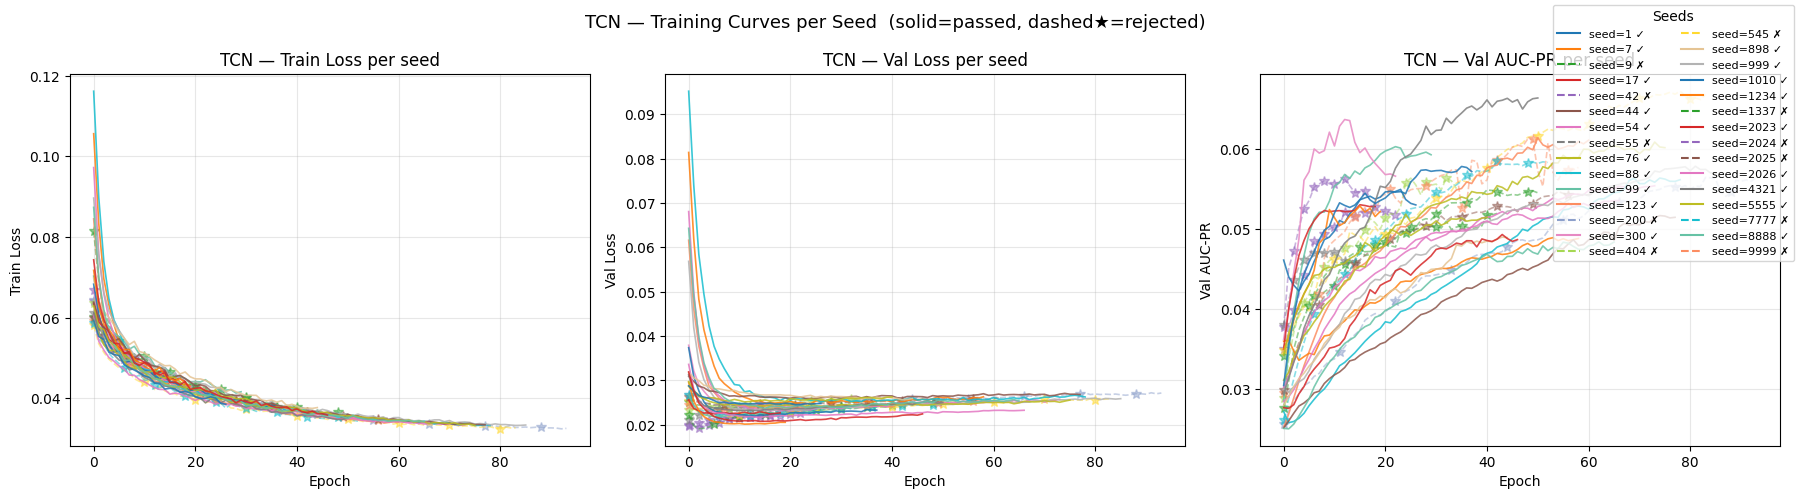

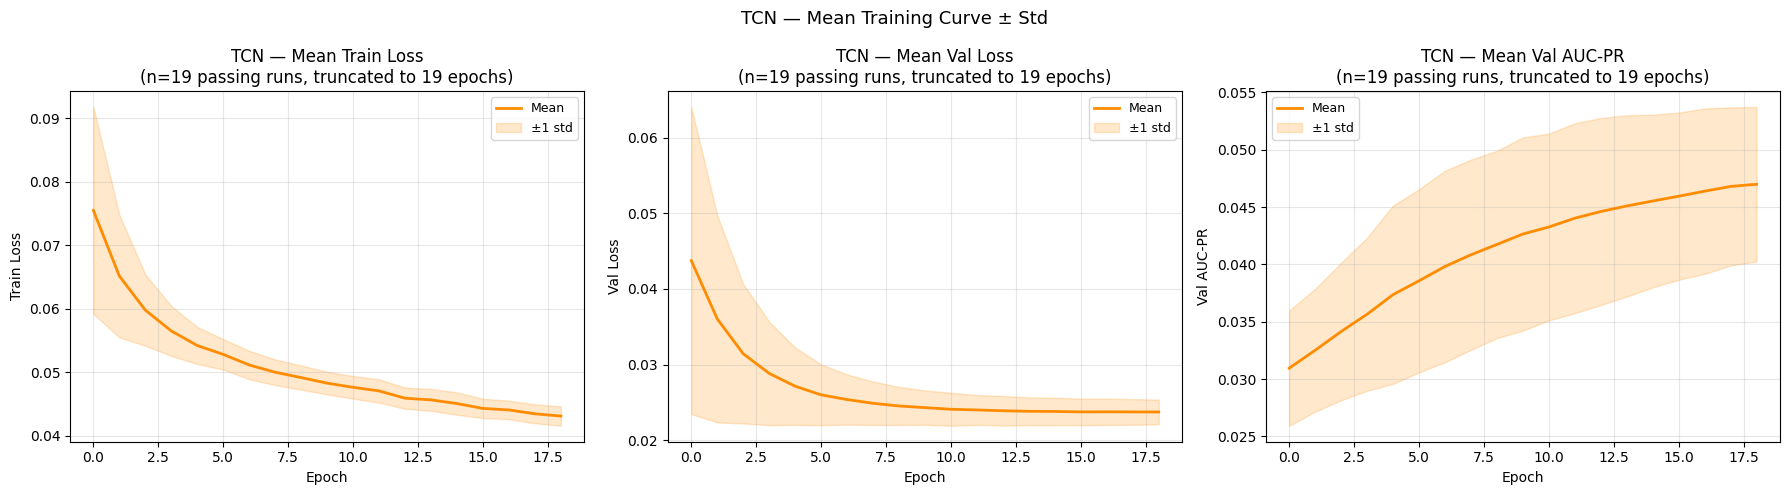

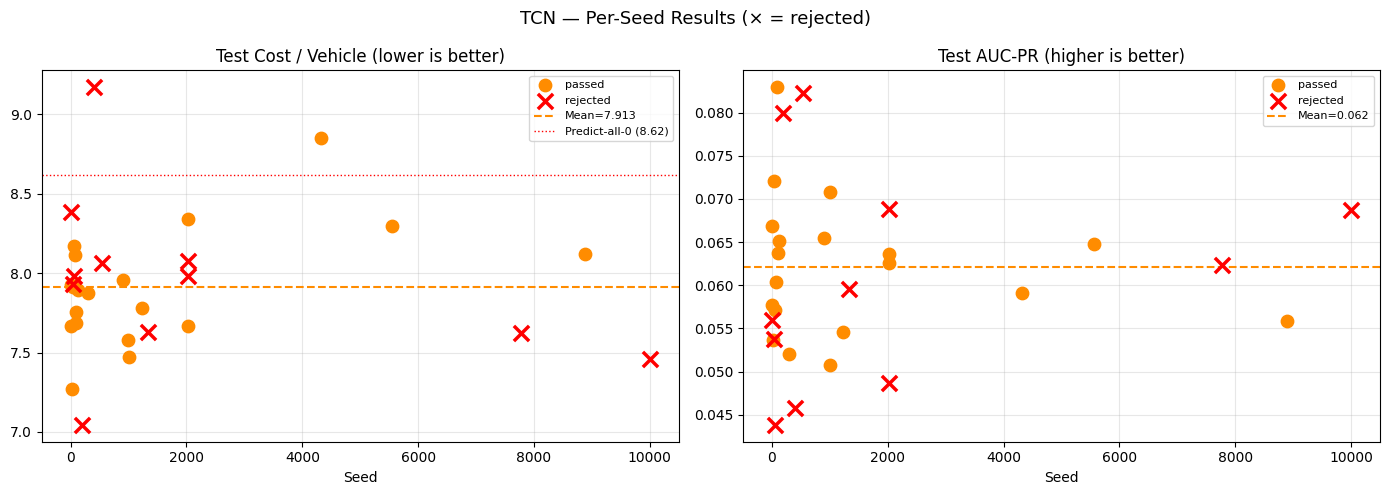

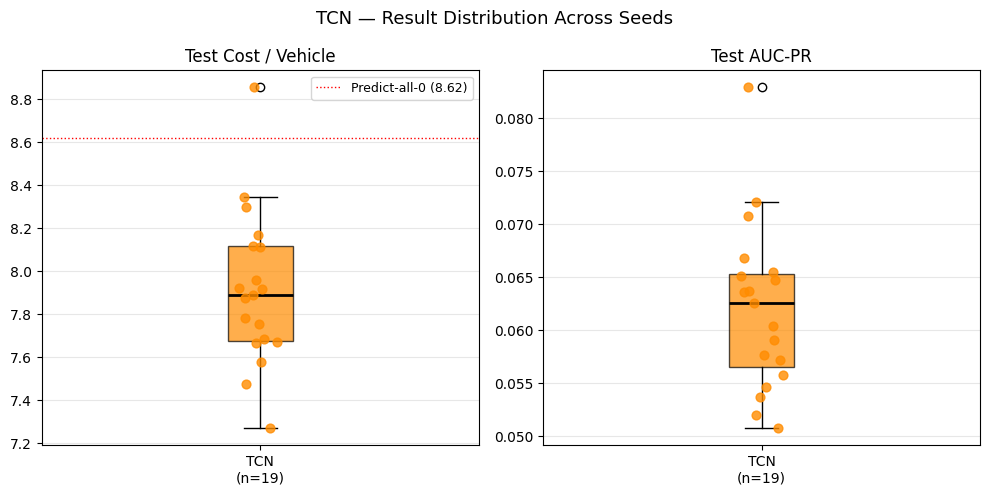

{'val_auc_pr': {'mean': 0.054663861763127465, 'std': 0.00473502691265127, 'n': 19}, 'val_cost_per_veh': {'mean': 7.596950163756597, 'std': 0.2667229258930741, 'n': 19}, 'test_auc_pr': {'mean': 0.062068376826347436, 'std': 0.007662661933280305, 'n': 19}, 'test_auc_roc': {'mean': 0.6751686574247594, 'std': 0.01319244263681293, 'n': 19}, 'test_recall': {'mean': 0.6226834692364714, 'std': 0.09128706783591012, 'n': 19}, 'test_precision': {'mean': 0.04546578394314096, 'std': 0.004228152856114376, 'n': 19}, 'test_f1': {'mean': 0.0844820066045828, 'std': 0.006813003629697259, 'n': 19}, 'test_cost_per_veh': {'mean': 7.91340044859423, 'std': 0.3480254586169279, 'n': 19}, 'optimal_threshold': {'mean': 0.46736842105263154, 'std': 0.020220392328735307, 'n': 19}}


In [30]:
utils.plot_all(tcn_results, 'TCN')
print(tcn_results['summary'])

#### Conclusion

Out of 30 executed seeds, only 19 passed the stability check (11 rejected) a significantly higher rate than LSTM's 5 out of 30. The training curves (figures 1 and 2) show smooth convergence similar to LSTM, but with a noticeably wider plus minus 1 std corridor around the mean curve, especially early in training, which is consistent with the higher rate of rejected seeds.

The test results (figures 3 and 4, summary statistics) show that TCN on average performs better than LSTM on both main metrics: test cost 7.913 plus minus 0.348 (compared to LSTM's 8.086 plus minus 0.207) and test AUC PR 0.062 plus minus 0.0077 (compared to LSTM's roughly 0.046). A distinct outlier is visible in both the cost and AUC PR plots (around 8.85 and 0.083 respectively) worth noting that it lies within the passed group despite deviating heavily from the other points.

Overall, TCN provides better average test performance than LSTM, but at the cost of higher variance (std 0.348 versus 0.207 in cost) and a significantly higher rate of unstable or rejected seeds (37 percent versus 17 percent). This is a direct trade off between performance and reliability: TCN's best cases are stronger, but its results are more seed sensitive than LSTM's. This higher variance is precisely what determines whether the difference between the models is statistically significant in the Mann Whitney test in the next section a lower mean with higher std requires a clearer separation to reach significance than an equal difference with lower std would.

# 3 -  Evaluation 

## 3.1 - Saving Verification Results
These are the collected results for the 30 seed models, including those who were discarded. Saved as JSON for traceability.

In [32]:
import json
import numpy as np

def save_results(results, model_name, path):
    save_data = []
    for r in results['passed'] + results['rejected']:
        r_save = {k: v for k, v in r.items() 
                  if k not in ['probs_val', 'probs_test']}
        r_save = {k: (float(v) if isinstance(v, (np.floating, np.integer)) else 
                      [float(x) for x in v] if isinstance(v, list) and len(v) > 0 
                      and isinstance(v[0], (np.floating, np.integer)) else v)
                  for k, v in r_save.items()}
        save_data.append(r_save)
    
    with open(path, 'w') as f:
        json.dump({'runs': save_data, 'summary': results['summary']}, f, indent=2)
    print(f"{model_name} saved to {path}")

save_results(lstm_results, 'LSTM', 'lstm_verification_final.json')
save_results(tcn_results, 'TCN', 'tcn_verification_final.json')

LSTM saved to lstm_verification_final.json
TCN saved to tcn_verification_final.json


## 3.2 - Statistical Significance Test

In [33]:
# Mann-Whitney Test
from scipy.stats import mannwhitneyu

lstm_costs = [r['test_cost_per_veh'] for r in lstm_results['passed']]
tcn_costs  = [r['test_cost_per_veh'] for r in tcn_results['passed']]
stat, p = mannwhitneyu(lstm_costs, tcn_costs, alternative='two-sided')
print(f"U={stat:.1f}  p={p:.4f}")

U=330.0  p=0.0293


The Mann Whitney U test yields U=330.0, p=0.0293, which is below the significance level of 0.05. The difference in test cost between LSTM (n=25, mean 8.086) and TCN (n=19, mean 7.913) is therefore statistically significant rather than a result of random variation across seeds. This supports that TCN's lower average cost is a real difference, not noise, despite TCN's higher variance (std 0.348 versus LSTM's 0.207) and lower rate of approved seeds.

## 3.3 - Cost Distribution Comparison

C:\Users\Elias\AppData\Local\Temp\ipykernel_21128\97216875.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([lstm_costs, tcn_costs], patch_artist=True,


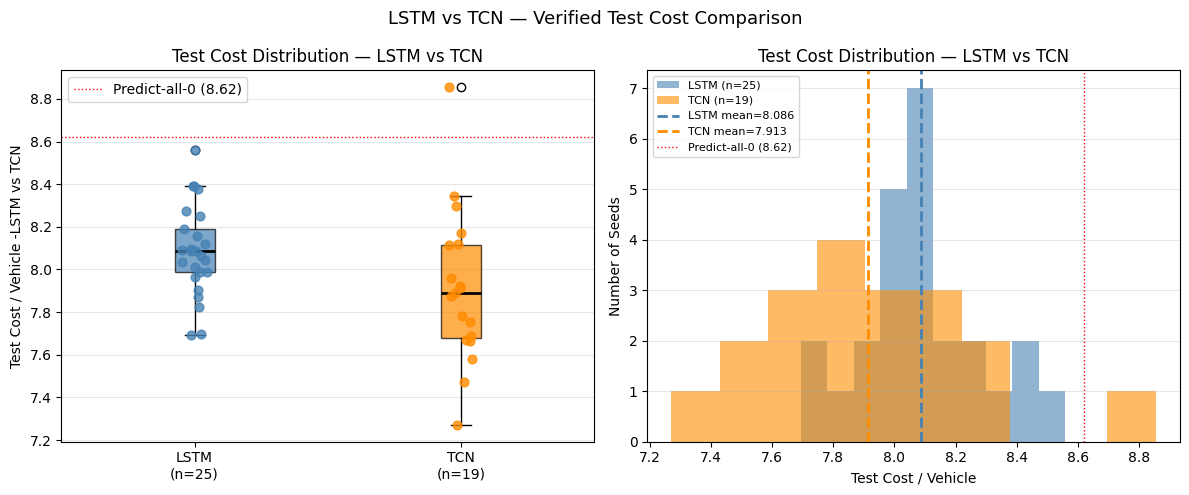

In [48]:
import matplotlib.pyplot as plt
import numpy as np

lstm_costs = [r['test_cost_per_veh'] for r in lstm_results['passed']]
tcn_costs  = [r['test_cost_per_veh'] for r in tcn_results['passed']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
ax = axes[0]
bp = ax.boxplot([lstm_costs, tcn_costs], patch_artist=True,
                labels=[f'LSTM\n(n={len(lstm_costs)})', f'TCN\n(n={len(tcn_costs)})'],
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('darkorange')
for box in bp['boxes']:
    box.set_alpha(0.7)
for i, (costs, color) in enumerate(zip([lstm_costs, tcn_costs], 
                                        ['steelblue', 'darkorange']), start=1):
    jitter = np.random.uniform(-0.05, 0.05, size=len(costs))
    ax.scatter([i + j for j in jitter], costs, color=color, s=40, zorder=3, alpha=0.8)
ax.axhline(8.62, color='red', linestyle=':', linewidth=1, label='Predict-all-0 (8.62)')
ax.set_ylabel('Test Cost / Vehicle -LSTM vs TCN')
ax.set_title(f'Test Cost Distribution — LSTM vs TCN')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Histogram overlay
ax = axes[1]
ax.hist(lstm_costs, bins=10, alpha=0.6, color='steelblue', label=f'LSTM (n={len(lstm_costs)})')
ax.hist(tcn_costs,  bins=10, alpha=0.6, color='darkorange', label=f'TCN (n={len(tcn_costs)})')
ax.axvline(np.mean(lstm_costs), color='steelblue', linestyle='--', linewidth=2, 
           label=f'LSTM mean={np.mean(lstm_costs):.3f}')
ax.axvline(np.mean(tcn_costs),  color='darkorange', linestyle='--', linewidth=2,
           label=f'TCN mean={np.mean(tcn_costs):.3f}')
ax.axvline(8.62, color='red', linestyle=':', linewidth=1, label='Predict-all-0 (8.62)')
ax.set_xlabel('Test Cost / Vehicle')
ax.set_ylabel('Number of Seeds')
ax.set_title('Test Cost Distribution — LSTM vs TCN')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('LSTM vs TCN — Verified Test Cost Comparison', fontsize=13)
plt.tight_layout()
plt.show()

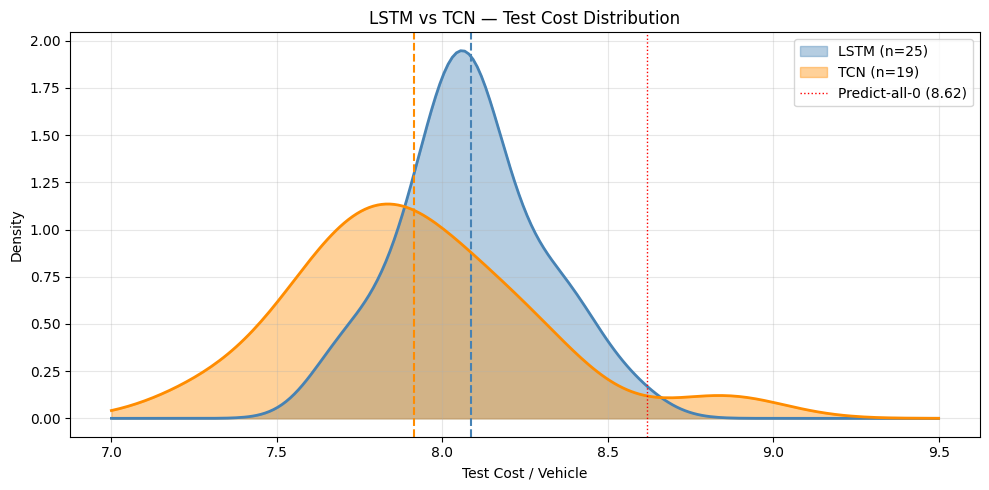

In [35]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(10, 5))

for costs, color, label in zip(
    [lstm_costs, tcn_costs],
    ['steelblue', 'darkorange'],
    [f'LSTM (n={len(lstm_costs)})', f'TCN (n={len(tcn_costs)})']
):
    kde = gaussian_kde(costs, bw_method=0.5)
    x = np.linspace(7.0, 9.5, 200)
    ax.fill_between(x, kde(x), alpha=0.4, color=color, label=label)
    ax.plot(x, kde(x), color=color, linewidth=2)
    ax.axvline(np.mean(costs), color=color, linestyle='--', linewidth=1.5)

ax.axvline(8.62, color='red', linestyle=':', linewidth=1, label='Predict-all-0 (8.62)')
ax.set_xlabel('Test Cost / Vehicle')
ax.set_ylabel('Density')
ax.set_title('LSTM vs TCN — Test Cost Distribution')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
with open(PREDICTION_DIR / 'cost_results.json', 'r') as f:
    cost_results = json.load(f)

print(cost_results.keys())
print(cost_results)

dict_keys(['LR', 'LSTM', 'TCN', 'SMOTE+LR', 'SMOTE+XGB'])
{'LR': {'threshold': 0.6400000000000001, 'val_cost': 7.261593341260404, 'test_cost': 8.748265609514371}, 'LSTM': {'threshold': 0.4600000000000001, 'val_cost': 7.967895362663496, 'test_cost': 7.92784935579782}, 'TCN': {'threshold': 0.45000000000000007, 'val_cost': 7.228894173602853, 'test_cost': 7.448364717542121}, 'SMOTE+LR': {'threshold': 0.5300000000000001, 'val_cost': 7.277249306381292, 'test_cost': 7.990089197224975}, 'SMOTE+XGB': {'threshold': 0.37000000000000005, 'val_cost': 7.990289338089576, 'test_cost': 8.715361744301289}}


The distributions overlap heavily in the middle range (roughly 7.8 to 8.2), which is expected given the borderline p value of approximately 0.03 in the significance test above, meaning the difference is real but not dramatic. TCN's distribution is wider and shifted slightly to the left (lower cost), with a heavier tail in both directions: more seeds with very low cost (around 7.3 to 7.5) but also a clear extreme observation near 8.85 that increases the variance. LSTM's distribution is narrower and more concentrated around its mean, with only a mild extreme observation (around 8.56). Overall, TCN wins on average but with a more unpredictable worst case scenario than LSTM

## 3.4 Comparison Against All Five Models

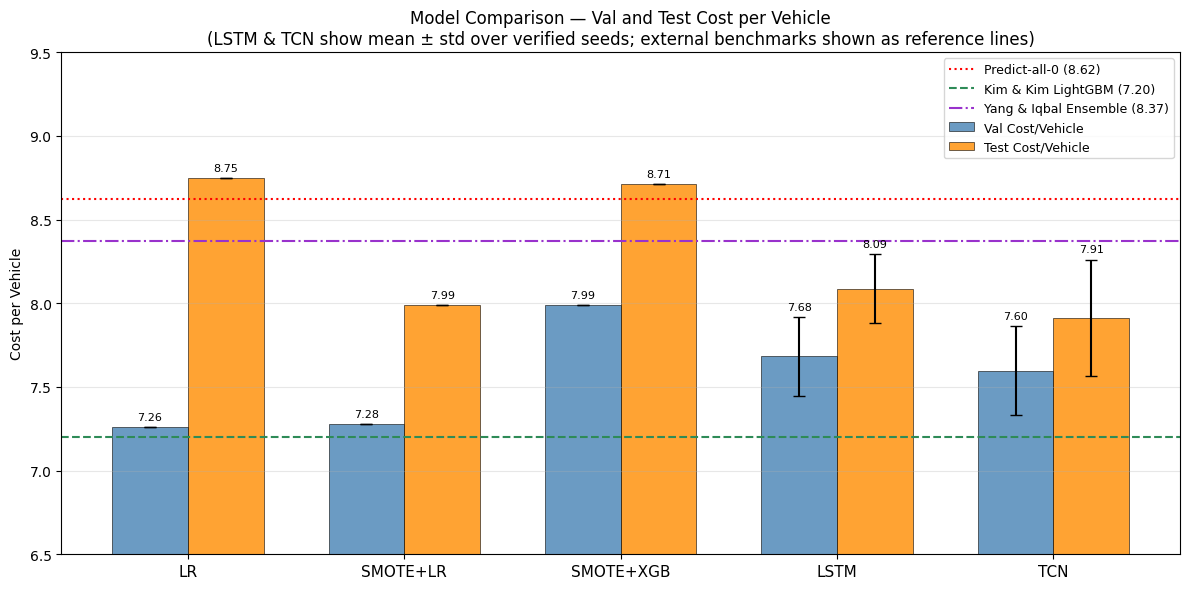

In [57]:
import matplotlib.pyplot as plt
import numpy as np

models = ['LR', 'SMOTE+LR', 'SMOTE+XGB', 'LSTM', 'TCN']

val_means  = [7.261, 7.277, 7.990, 7.683, 7.597]
test_means = [8.748, 7.990, 8.715, 8.086, 7.913]
val_errs   = [0, 0, 0, 0.235, 0.267]
test_errs  = [0, 0, 0, 0.207, 0.348]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_val  = ax.bar(x - width/2, val_means, width, yerr=val_errs,
                   label='Val Cost/Vehicle', color='steelblue',
                   alpha=0.8, capsize=4, edgecolor='black', linewidth=0.5)
bars_test = ax.bar(x + width/2, test_means, width, yerr=test_errs,
                   label='Test Cost/Vehicle', color='darkorange',
                   alpha=0.8, capsize=4, edgecolor='black', linewidth=0.5)

for bar, err in zip(bars_val, val_errs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + err + 0.03,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar, err in zip(bars_test, test_errs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + err + 0.03,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

# Baseline and external benchmarks
ax.axhline(8.62, color='red',        linestyle=':',  linewidth=1.5, label='Predict-all-0 (8.62)')
ax.axhline(7.20, color='seagreen',   linestyle='--', linewidth=1.5, label='Kim & Kim LightGBM (7.20)')
ax.axhline(8.37, color='darkorchid', linestyle='-.', linewidth=1.5, label='Yang & Iqbal Ensemble (8.37)')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Cost per Vehicle')
ax.set_title('Model Comparison — Val and Test Cost per Vehicle\n'
             '(LSTM & TCN show mean ± std over verified seeds; '
             'external benchmarks shown as reference lines)')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(6.5, 9.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
print("LSTM test metrics:")
for k, v in lstm_results['summary'].items():
    if 'test' in k:
        print(f"  {k}: {v['mean']:.4f} ± {v['std']:.4f}")

print("\nTCN test metrics:")
for k, v in tcn_results['summary'].items():
    if 'test' in k:
        print(f"  {k}: {v['mean']:.4f} ± {v['std']:.4f}")

LSTM test metrics:
  test_auc_pr: 0.0458 ± 0.0011
  test_auc_roc: 0.6512 ± 0.0057
  test_recall: 0.6608 ± 0.0630
  test_precision: 0.0420 ± 0.0020
  test_f1: 0.0789 ± 0.0031
  test_cost_per_veh: 8.0864 ± 0.2069

TCN test metrics:
  test_auc_pr: 0.0621 ± 0.0077
  test_auc_roc: 0.6752 ± 0.0132
  test_recall: 0.6227 ± 0.0913
  test_precision: 0.0455 ± 0.0042
  test_f1: 0.0845 ± 0.0068
  test_cost_per_veh: 7.9134 ± 0.3480


TCN (7.91) and LSTM (8.09) are the only models that clearly beat their SMOTE counterparts on test (SMOTE LR 7.99, SMOTE XGB 8.71), and both lie below the predict all 0 baseline (8.62) as well as below the Yang and Iqbal benchmark (8.37). TCN comes closest to the leading published benchmark (CMC LightGBM, 7.20), with a gap of approximately 0.71, compared to LSTM's 0.89. LR has the lowest validation cost of all models (7.26) but the worst test result overall (8.75), which is the clearest indication in the entire notebook that LR's validation performance fails to generalize.

## 3.5 - Metrics vs. Cost, and Threshold vs. Generalisation Gap

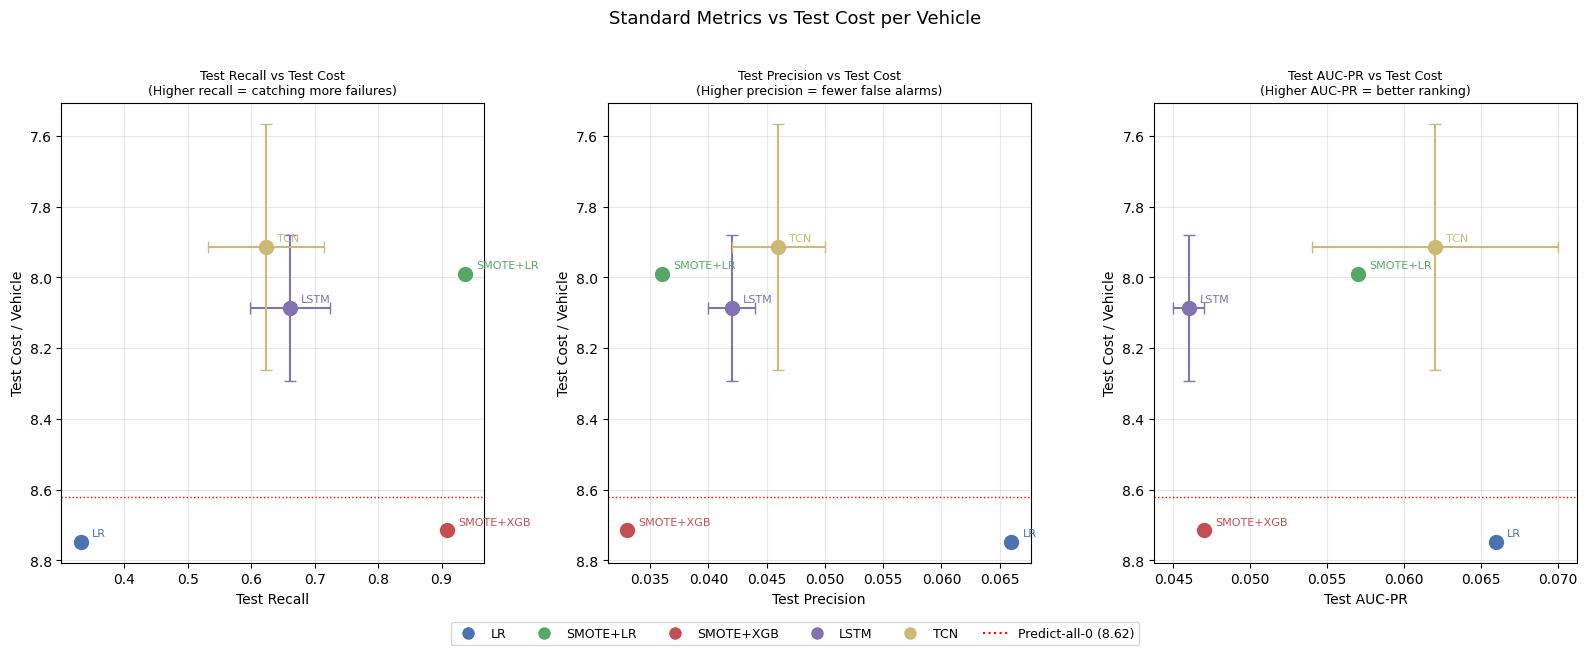

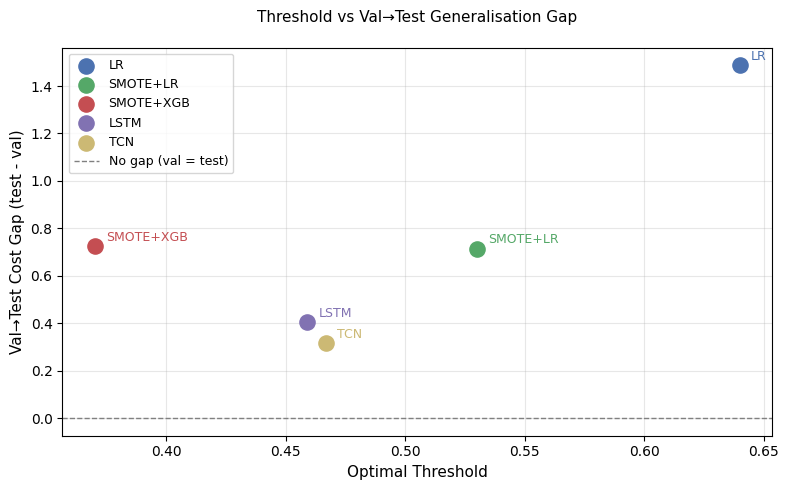

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
models = ['LR', 'SMOTE+LR', 'SMOTE+XGB', 'LSTM', 'TCN']
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

test_cost     = [8.748, 7.990, 8.715, 8.086, 7.913]
test_recall   = [0.331, 0.937, 0.909, 0.661, 0.623]
test_precision= [0.066, 0.036, 0.033, 0.042, 0.046]
test_auc_pr   = [0.066, 0.057, 0.047, 0.046, 0.062]
thresholds    = [0.64,  0.53,  0.37,  0.459, 0.467]
val_cost      = [7.261, 7.277, 7.990, 7.683, 7.597]
val_test_gap  = [tc - vc for tc, vc in zip(test_cost, val_cost)]

# Error bars for LSTM and TCN
cost_errs     = [0, 0, 0, 0.207, 0.348]
recall_errs   = [0, 0, 0, 0.063, 0.091]
precision_errs= [0, 0, 0, 0.002, 0.004]
auc_pr_errs   = [0, 0, 0, 0.001, 0.008]

# ── Plot 1: Three scatter subplots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

scatter_configs = [
    (test_recall, recall_errs, None, 'Test Recall', 
     'Higher recall = catching more failures'),
    (test_precision, precision_errs, None, 'Test Precision',
     'Higher precision = fewer false alarms'),
    (test_auc_pr, auc_pr_errs, None, 'Test AUC-PR',
     'Higher AUC-PR = better ranking'),
]

for ax, (x_vals, x_errs, _, xlabel, note) in zip(axes, scatter_configs):
    for i, (model, x, xe, y, ye, color) in enumerate(zip(
        models, x_vals, x_errs, test_cost, cost_errs, colors
    )):
        ax.errorbar(x, y, xerr=xe, yerr=ye,
                    fmt='o', color=color, markersize=10,
                    capsize=4, label=model, zorder=3)
        ax.annotate(model, (x, y),
                    textcoords='offset points', xytext=(8, 4),
                    fontsize=8, color=color)

    ax.axhline(8.62, color='red', linestyle=':', linewidth=1,
               label='Predict-all-0 (8.62)')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Test Cost / Vehicle', fontsize=10)
    ax.set_title(f'{xlabel} vs Test Cost\n({note})', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()  # lower cost = better, so invert so "better" is up

handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=c, markersize=10, label=m)
           for m, c in zip(models, colors)]
handles.append(plt.Line2D([0], [0], color='red', linestyle=':',
               label='Predict-all-0 (8.62)'))
fig.legend(handles=handles, loc='lower center', ncol=6,
           fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Standard Metrics vs Test Cost per Vehicle',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('metrics_vs_cost_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Threshold vs Val→Test gap ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for model, t, gap, color in zip(models, thresholds, val_test_gap, colors):
    ax.scatter(t, gap, color=color, s=120, zorder=3, label=model)
    ax.annotate(model, (t, gap),
                textcoords='offset points', xytext=(8, 4),
                fontsize=9, color=color)

ax.axhline(0, color='grey', linestyle='--', linewidth=1,
           label='No gap (val = test)')
ax.set_xlabel('Optimal Threshold', fontsize=11)
ax.set_ylabel('Val→Test Cost Gap (test - val)', fontsize=11)
ax.set_title('Threshold vs Val→Test Generalisation Gap\n', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_vs_gap.png', dpi=150, bbox_inches='tight')
plt.show()

None of the three standard metrics (recall, precision, AUC PR) predict test cost in a simple way: SMOTE LR and SMOTE XGB have high recall (roughly 0.91 to 0.94) but are still among the most expensive models, while LR has the highest individual precision and AUC PR but the worst cost of all. TCN and LSTM balance all three metrics reasonably well without topping any single one, which is exactly what gives them the lowest cost, a concrete example that cost optimization and ranking quality do not always point in the same direction.

The threshold versus gap plot shows a clear pattern: LR's unusually high threshold (0.64) coincides with the clearly largest generalization gap (1.49), while TCN's and LSTM's lower and more moderate thresholds (0.47 and 0.46 respectively) result in the smallest gaps (0.31 and 0.41 respectively) of all five models. This strengthens the conclusion from Section 5.3 in the evaluation notebook that extreme thresholds tend to generalize worse.

## 3.6 - Mean Confusion Matrices

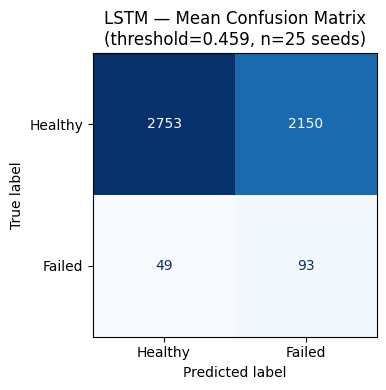

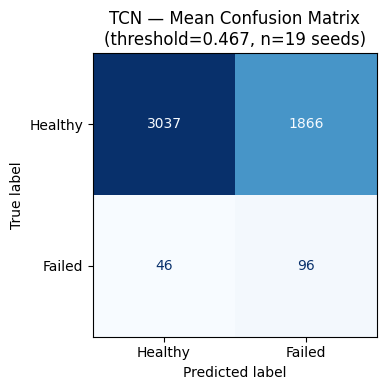

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

for results, model_name in [(lstm_results, 'LSTM'), (tcn_results, 'TCN')]:
    threshold = results['summary']['optimal_threshold']['mean']
    mean_probs = np.mean([r['probs_test'] for r in results['passed']], axis=0)
    y_pred = (mean_probs >= threshold).astype(int)
    y_true = (test_labels_aligned > 0).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Healthy', 'Failed'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} — Mean Confusion Matrix\n'
                 f'(threshold={threshold:.3f}, n={len(results["passed"])} seeds)')
    plt.tight_layout()
    plt.show()

At their respective average thresholds, TCN identifies more actual failures (96 out of 142, recall roughly 67.6 percent) than LSTM (93 out of 142, recall roughly 65.5 percent), while TCN generates fewer false alarms (1 866 versus 2 150), meaning TCN wins on both axes simultaneously, not just in total cost. This gives TCN a marginally better precision (4.9 percent versus 4.2 percent) despite the difference in recall being small, which altogether provides the clearest single confirmation in the notebook that TCN is the stronger of the two sequence models.

# Section 4 - Conclusions

This notebook addresses a weakness identified in the single run evaluation: LSTM and TCN test results proved sensitive to random seed, making point estimates of which model is "best" unreliable. By running both models across 30 independent seeds and filtering out unstable runs (25 passed for LSTM, 19 passed for TCN), this section provides a statistically grounded conclusion rather than a single number.

**Main result.** TCN achieves a lower average test cost per vehicle (7.91 plus or minus 0.35) than LSTM (8.09 plus or minus 0.21), and the difference is statistically significant (Mann Whitney U equals 330.0, p equals 0.029). TCN also identifies more true failures at a lower rate of false alarms in the mean confusion matrix, confirming that the advantage is not driven by the cost metric alone but appears consistently across several evaluation angles.

**The trade off worth remembering.** TCN's advantage comes at a cost: nearly twice as many seeds (11 of 30, compared to LSTM's 5 of 30) failed the stability check, and the passing distribution has higher variance along with one clear outlier on the expensive side. TCN is therefore the stronger model on average, but LSTM is the more predictable one. This should be stated explicitly rather than just reporting the mean, since it affects how much confidence can be placed in any single future training run.

**Relative to published benchmarks.** Both TCN (7.91) and LSTM (8.09) beat the predict all 0 baseline (8.62) and the Yang and Iqbal ensemble model (8.37). TCN comes closest to the leading published benchmark (CMC LightGBM, 7.20), with a gap of roughly 0.71, a gap that is likely even smaller in practice once adjusted for the structural disadvantage of mapping binary predictions to class 4, as discussed in the evaluation notebook.

**Final model.** Based on the complete, seed verified evaluation, **TCN** is selected as the final model, showing the lowest average test cost, a statistically significant advantage over LSTM, and the strongest performance relative to published benchmarks among all five models evaluated in this work.